# nb_02 — Light-curve property histograms

Goal (see `docs/SPEC_V01.md`, rough plan step 2): histograms for `nDiaSources`, and per-object
light-curve statistics — duration, cadence, amplitude — computed from the nested `diaSource`
column via `lsdb`'s `map_rows`. Works on the full HQ sample nb_01 wrote to `dp2_subset`
(`nDiaSources > 100`, ~399k objects spanning the whole `diaObject` collection) instead of
nb-v01's 5-field subset — there's no `field` column to split by anymore, so the plots below
treat the sample as a whole rather than stitching together per-partition/per-field panels.

**Resolves one of the spec's open questions.** `diaSource` carries both a difference-image
flux/mag (`psfFlux`/`psfMag` — noisy, sometimes negative → `NaN` mag) *and* an absolute,
calibrated science-image flux/mag (`scienceFlux`/`scienceMag` — a stable per-epoch baseline
value, confirmed against nb_01's subset). So the "diff fluxes aren't informative for
histograms" concern doesn't need a fix (no mag conversion, no Object-catalog crossmatch) —
`scienceMag` already works directly for amplitude-style statistics.

**Deferred to later, not attempted here:** the spec's rise/fall/peak-location stats for
detected transients need an actual transient-detection criterion first, which belongs with
the type-specific search work in the spec's "Specific types search" section, not a
general-purpose histogram notebook.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lsdb
from datapaths import Datapaths

sys.path.insert(0, str(Path.cwd().parent / "src"))
from dataio import select_slice

dp = Datapaths()
hq_cat = lsdb.open_catalog(dp["dp2_subset"] / "dia_object_lc_hq")
print(hq_cat.npartitions, "partitions")
hq_cat

## 0. Pick a slice of the HQ sample to explore

`hq_cat` above is lazy and spans the *whole* HQ collection (~399k objects across 4445
partitions) — too much to casually pull into memory or eyeball. `select_slice`
(`src/dataio/hq_sample.py`) gets you a small, concrete piece of it instead: either one
partition (fast, zero query cost, but an arbitrary sky-tile boundary) or a cone search around
a coordinate you pick (a more intuitive "give me this patch of sky", at the cost of a live
query). Toggle `SLICE_MODE` below. Nothing else in this notebook depends on this slice — the
histograms further down work on the whole sample — it's just something concrete to look at.

In [ ]:
SLICE_MODE = "partition"  # "partition" or "cone_search"
PARTITION_INDEX = 200
CONE_RA, CONE_DEC, CONE_RADIUS_ARCSEC = 150.0, 2.0, 1800  # ~0.5 deg

slice_cat = select_slice(
    hq_cat,
    mode=SLICE_MODE,
    partition_index=PARTITION_INDEX,
    ra=CONE_RA,
    dec=CONE_DEC,
    radius_arcsec=CONE_RADIUS_ARCSEC,
)
slice_df = slice_cat.compute()
print(f"{SLICE_MODE}: {len(slice_df)} objects")
slice_df.drop(columns=["diaSource", "diaObjectForcedSource"]).head()

## 1. `nDiaSources` histogram

`nDiaSources` is a flat (non-nested) column, so this is a plain `.compute()` + `plt.hist` — no
`map_rows` needed. Reading it across the whole HQ sample (4445 partitions, ~399k objects)
takes about a minute even though it's only two flat columns — partition overhead, not data
volume. One combined histogram now, no per-field panel: the HQ sample has no `field` column,
and the point of this refactor is to treat it as one sample rather than stitch together
per-partition subplots.

In [ ]:
flat_df = hq_cat[["diaObjectId", "nDiaSources"]].compute()
print(flat_df.shape)
flat_df["nDiaSources"].describe()

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.5))

bins = np.logspace(np.log10(flat_df["nDiaSources"].min()), np.log10(flat_df["nDiaSources"].max()), 40)
ax.hist(flat_df["nDiaSources"], bins=bins, color="C0")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("nDiaSources")
ax.set_ylabel("objects")
ax.set_title(f"whole HQ sample (n={len(flat_df):,})")

fig.tight_layout()

## 2. Per-object light-curve statistics via `map_rows`

`catalog.map_rows(func, columns=[...], meta=...)` runs `func` once per top-level row (one
diaObject), handing it the requested nested sub-columns as plain numpy arrays. Unlike
nb-v01 (where this ran on an already-`.compute()`d 7,036-object subset), this runs directly on
the lazy `hq_cat` — the whole ~399k-object HQ sample, per the backlog's ask that LC stats be
calculated for the whole HQ sample rather than a hand-picked slice.

Two deliberate choices, both because bands don't share a cadence (same issue the spec flags
for color computation):
- **Duration and cadence gap use all bands combined** — they're about time sampling, not
  flux, so mixing bands is fine and matches "how long/how densely was this object monitored,
  period" rather than a per-band question.
- **Amplitude is computed per band** (`{band}_amp_p90p10`), *never* mixing bands — a g-band
  and r-band magnitude differ by the object's color, not by variability, so combining them
  would inflate "amplitude" with a color offset rather than measure real variation. We use
  the 10th-90th percentile range rather than min/max, per the spec's "robust-amplitude (with
  outliers discarded)" — a couple of noisy points at the tails don't blow up the estimate.

### Heavy-calculation flag

`map_rows` below now runs once per object across the *whole* HQ sample (~399k objects, ~57x
nb-v01's 5-field subset) — a light per-object computation (sort + percentiles, no
periodogram), so likely minutes rather than nb_04's multiband hours, but not actually timed
against the full sample in this session (only checked at small scale — see
`docs/changelog.md`). Also collapses what nb-v01 split across two cells (compute, then a
separate write/register step) into one `map_rows(..., append_columns=True)` call, per that
version's own "Next" note — avoids materializing the whole HQ collection into memory twice.
`RUN_HEAVY_CALC` gates the whole thing; leave it `False` (the default) to read the stats back
from the already-registered `dia_object_lc_hq_with_stats` instead. **First time populating
this branch's registry:** set it `True` once so that collection actually exists before nb_03
tries to read it.

In [4]:
RUN_HEAVY_CALC = False

In [ ]:
BANDS = "ugrizy"


def lc_stats(row):
    t = np.asarray(row["diaSource.midpointMjdTai"], dtype=float)
    mag = np.asarray(row["diaSource.scienceMag"], dtype=float)
    band = np.asarray(row["diaSource.band"])

    order = np.argsort(t)
    t, mag, band = t[order], mag[order], band[order]

    duration = float(t[-1] - t[0]) if len(t) > 1 else 0.0
    gaps = np.diff(t)
    median_gap = float(np.median(gaps)) if len(gaps) > 0 else np.nan

    out = {"duration_days": duration, "median_cadence_gap_days": median_gap}
    for b in BANDS:
        band_mag = mag[band == b]
        band_mag = band_mag[np.isfinite(band_mag)]
        # require >= 3 points so the percentile range means something
        out[f"{b}_amp_p90p10"] = (
            float(np.percentile(band_mag, 90) - np.percentile(band_mag, 10))
            if len(band_mag) >= 3
            else np.nan
        )
    return pd.Series(out)


with_stats_path = dp["dp2_subset"] / "dia_object_lc_hq_with_stats"
stat_cols = ["duration_days", "median_cadence_gap_days"] + [f"{b}_amp_p90p10" for b in BANDS]

if RUN_HEAVY_CALC:
    meta = {"duration_days": "f8", "median_cadence_gap_days": "f8"}
    meta |= {f"{b}_amp_p90p10": "f8" for b in BANDS}

    with_stats_cat = hq_cat.map_rows(
        lc_stats,
        columns=["diaSource.midpointMjdTai", "diaSource.scienceMag", "diaSource.band"],
        meta=meta,
        append_columns=True,
    )
    # Route through compute() + from_dataframe() before writing — writing a
    # map_rows(..., append_columns=True) result directly produces a margin cache with a
    # misnamed spatial index (nb_03 found this first; see its section 1 markdown).
    merged_df = with_stats_cat.compute()
    lsdb.from_dataframe(merged_df).write_catalog(with_stats_path, overwrite=True, create_thumbnail=False, progress_bar=False)
    print("wrote", with_stats_path)

    dp.register(
        name="dia_object_lc_hq_with_stats",
        type="dp2_subset",
        fmt="hats-collection",
        src_path=str(with_stats_path / "collection.properties"),
        tags=["nb02", "dp2", "diaObject", "lc-stats", "hq"],
        inputs=["dia_object_lc_hq"],
        notes=(
            "dia_object_lc_hq plus duration_days, median_cadence_gap_days (all bands) and "
            "{band}_amp_p90p10 (per band, scienceMag) columns, from nb_02."
        ),
        overwrite_history=True,
    )
    dp.print_paths(name="dia_object_lc_hq_with_stats")
else:
    print(f"RUN_HEAVY_CALC=False — skipping map_rows/write/register; {with_stats_path} already up to date.")

### Read the stats back

Reopen `dia_object_lc_hq_with_stats` regardless of whether `RUN_HEAVY_CALC` just wrote it or
it was already there — the histograms below only need the flat stat columns, not the nested
light curves.

In [ ]:
with_stats_cat = lsdb.open_catalog(with_stats_path)
stats_df = with_stats_cat[stat_cols].compute()
print(stats_df.shape)
stats_df.describe()

## 3. Histograms: duration and cadence gap

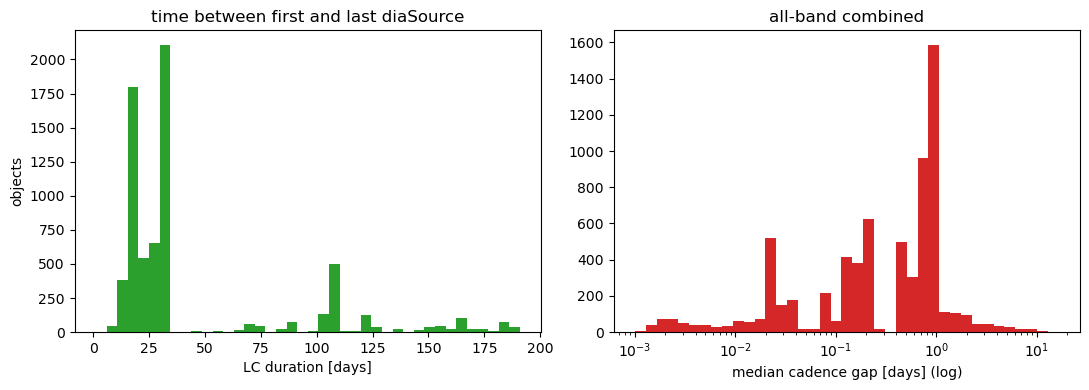

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(stats_df["duration_days"], bins=40, color="C2")
axes[0].set_xlabel("LC duration [days]")
axes[0].set_ylabel("objects")
axes[0].set_title("time between first and last diaSource")

gap = stats_df["median_cadence_gap_days"]
axes[1].hist(gap[gap > 0], bins=np.logspace(np.log10(max(gap[gap > 0].min(), 1e-3)), np.log10(gap.max()), 40), color="C3")
axes[1].set_xscale("log")
axes[1].set_xlabel("median cadence gap [days] (log)")
axes[1].set_title("all-band combined")

fig.tight_layout()

## 4. Histograms: per-band robust amplitude

One panel per band, so the very different sample sizes per band (`u` in particular — DP2's
LSSTCam observations spent little time there) stay visible rather than getting averaged away.

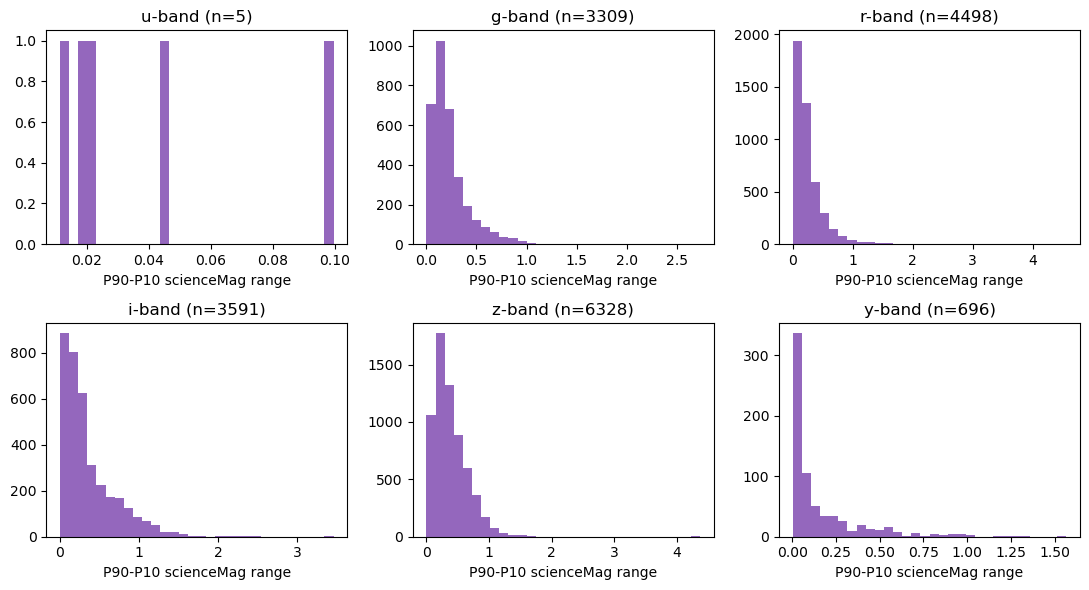

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(11, 6))

for ax, b in zip(axes.flat, BANDS):
    values = stats_df[f"{b}_amp_p90p10"].dropna()
    if len(values) > 0:
        ax.hist(values, bins=30, color="C4")
    ax.set_title(f"{b}-band (n={len(values)})")
    ax.set_xlabel("P90-P10 scienceMag range")

fig.tight_layout()

## Next

`dia_object_lc_hq_with_stats` is registered (once `RUN_HEAVY_CALC=True` has been run at least
once on this branch) and has the light curves plus the new stat columns together — no join
needed. nb_03 picks up from here for color-mag/color-color plots.

Open questions carried forward, not resolved here:
- **Not yet timed or run at full HQ scale.** The `map_rows`/write/register pass was only
  checked against a small slice in this session (see `docs/changelog.md`) — whoever runs
  `RUN_HEAVY_CALC=True` for real first should watch memory/time and update that entry.
- Whether P90-P10 is the right robustness choice, or something else (sigma-clipped std, MAD)
  would serve nb_04's period-finding work better as a shared amplitude definition.
- `median_cadence_gap_days` mixes bands; worth adding a per-band version once it's clear
  whether nb_04's period search wants combined or per-band cadence.
- Rewriting the whole collection every time a stat definition changes is fine at HQ-sample
  size (~399k objects) but won't scale to `dp2_filtered` (~300 GB) — worth revisiting whether
  `map_rows` + `write_catalog` is still the right approach there, or whether stats should
  stay a separate, cheaply-regenerable side table once the target is the full collection.